/tmp/ipykernel_52025/2806897987.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


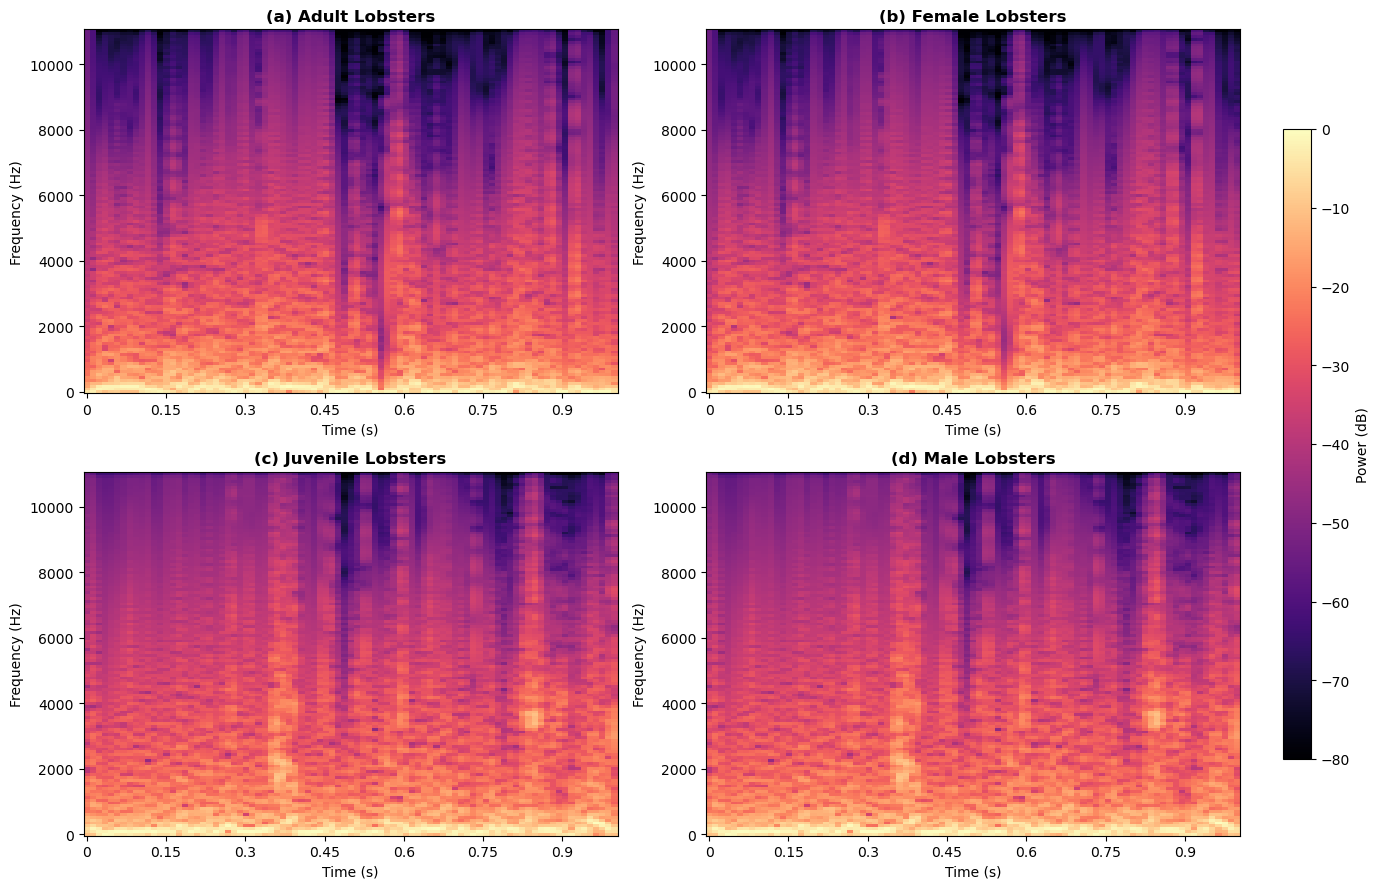


Saved 1-second spectrograms to: lobster_spectrograms_1sec.png


In [4]:
# ============================================================
# LOBSTER BIOACOUSTICS SPECTROGRAMS (1 SECOND CLIPS)
# ============================================================

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# ============================================================
# ROOT DATASET DIRECTORY
# ============================================================
BASE_DIR = "/home/feliciano/LOBSTER SOUNDS/DatasetClass"

# ============================================================
# FOLDER NAMES
# ============================================================
CLASS_FOLDERS = {
    "Adult Lobsters": os.path.join(BASE_DIR, "adult_lobsters"),
    "Female Lobsters": os.path.join(BASE_DIR, "female_lobsters"),
    "Juvenile Lobsters": os.path.join(BASE_DIR, "juvenile_lobsters"),
    "Male Lobsters": os.path.join(BASE_DIR, "male_lobsters"),
}

# ============================================================
# AUDIO SETTINGS - FIXED TO 1 SECOND
# ============================================================
SR = 22050
SECONDS = 1  # <--- Changed from 3 to 1
NFFT = 1024
HOP = 256
NMELS = 128

# ============================================================
# SELECT BEST EXAMPLE FILE
# ============================================================
def best_wav(folder):
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".wav")])
    if len(files) == 0:
        raise ValueError(f"No WAV files found in {folder}")

    best_file = None
    best_energy = -1

    for f in files:
        path = os.path.join(folder, f)
        try:
            # We only need a small portion to check energy
            y, _ = librosa.load(path, sr=SR, duration=SECONDS)
            energy = np.mean(np.abs(y))
            if energy > best_energy:
                best_energy = energy
                best_file = path
        except:
            pass
    return best_file

# ============================================================
# LOAD AUDIO CLIP (STRICT 1 SEC)
# ============================================================
def load_clip(path):
    # Load exactly the duration specified
    y, sr = librosa.load(path, sr=SR, duration=SECONDS)

    # Calculate target length in samples
    target_samples = SR * SECONDS

    # Ensure it is exactly 1 second (handle files shorter than 1s)
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)))
    else:
        y = y[:target_samples]

    return y, sr

# ============================================================
# CREATE MEL SPECTROGRAM
# ============================================================
def make_spec(y, sr):
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=NFFT,
        hop_length=HOP,
        n_mels=NMELS
    )
    return librosa.power_to_db(S, ref=np.max)

# ============================================================
# PREPARE DATA
# ============================================================
selected = {}
for label, folder in CLASS_FOLDERS.items():
    if not os.path.exists(folder):
        print(f"Warning: Folder not found {folder}")
        continue
    selected[label] = best_wav(folder)

# ============================================================
# PLOT 2x2 PANEL
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

labels = ["Adult Lobsters", "Female Lobsters", "Juvenile Lobsters", "Male Lobsters"]
titles = ["(a) Adult Lobsters", "(b) Female Lobsters", "(c) Juvenile Lobsters", "(d) Male Lobsters"]

for ax, title, label in zip(axes.ravel(), titles, labels):
    if label not in selected or selected[label] is None:
        continue
        
    y, sr = load_clip(selected[label])
    spec = make_spec(y, sr)

    img = librosa.display.specshow(
        spec,
        sr=sr,
        hop_length=HOP,
        x_axis="time",
        y_axis="hz",
        ax=ax
    )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")

# Global colorbar
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(img, cax=cbar_ax, label="Power (dB)")

plt.tight_layout(rect=[0, 0, 0.9, 1])

# ============================================================
# SAVE FIGURE
# ============================================================
outfile = "lobster_spectrograms_1sec.png"
plt.savefig(outfile, dpi=600, bbox_inches="tight")
plt.show()

print(f"\nSaved 1-second spectrograms to: {outfile}")